In [1]:
import numpy as np
import xarray as xr
from glob import glob
import random
import pandas as pd


import os
from tqdm.notebook import tqdm
import re

import pop_tools

%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import cm
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import StrMethodFormatter
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


from matplotlib.image import imread
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import util

from scipy.spatial import ConvexHull, Delaunay

## Figure 2

In [2]:
whole_ds_dor = xr.open_dataset(f'../data/dor_eff_maps.nc')
whole_ds_dor = util.pop_add_cyclic(whole_ds_dor)

In [3]:
whole_ds_dor = whole_ds_dor.set_coords(['TLAT', 'TLONG'])
whole_ds_dor_mean = whole_ds_dor.mean(dim='season')
whole_ds_dor_std = whole_ds_dor.std(dim='season')

/global/homes/m/mzhou/miniconda3/envs/mcdr-atlas/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [4]:
Pacific_polygon_masks = np.load('../data/polygon_data/Pacific_final_polygon_mask.npy')
Atlantic_polygon_masks = np.load('../data/polygon_data/Atlantic_final_polygon_mask.npy')

Pacific_centers = np.load('../data/polygon_data/Pacific_final_cluster_centers.npy', allow_pickle=True)
Atlantic_centers = np.load('../data/polygon_data/Atlantic_final_cluster_centers.npy', allow_pickle=True)

dor_curves = xr.open_dataset('../data/dor_efficiency_curves.nc')

In [5]:
def extract_unique(da, window=30, bin_size=3):

    # Get unique values
    unique_vals_erw = np.unique(da.values[~np.isnan(da.values)])
    
    # Create list to store the results
    selected_lat_erw = []
    
    for val in unique_vals_erw:
        mask = (da == val)
        # Find the first index where this value occurs
        idx = np.argwhere(mask.values)
        if idx.size > 0:
            lat_idx, lon_idx = idx[0]
            # Select that point from the DataArray
            point = da.isel(nlat=lat_idx, nlon=lon_idx)
            selected_lat_erw.append(point.TLAT.item())

    df = pd.DataFrame({'lat': selected_lat_erw, 'val': unique_vals_erw})
    
    df = df.sort_values('lat')
    window_size = window  
    df['val_smooth'] = df['val'].rolling(window=window_size, center=True, min_periods=1).mean()
        
    bins = np.arange(df['lat'].min(), df['lat'].max() + 1, bin_size)
    df['lat_bin'] = pd.cut(df['lat'], bins=bins)
    mean_vals = df.groupby('lat_bin')[['lat', 'val']].mean().dropna()
    return df, mean_vals

/tmp/ipykernel_1159429/3946745841.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_vals = df.groupby('lat_bin')[['lat', 'val']].mean().dropna()
/tmp/ipykernel_1159429/3946745841.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_vals = df.groupby('lat_bin')[['lat', 'val']].mean().dropna()
/tmp/ipykernel_1159429/3946745841.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_vals = df.groupby('lat_bin

CPU times: user 12.8 s, sys: 1.83 s, total: 14.7 s
Wall time: 15.2 s


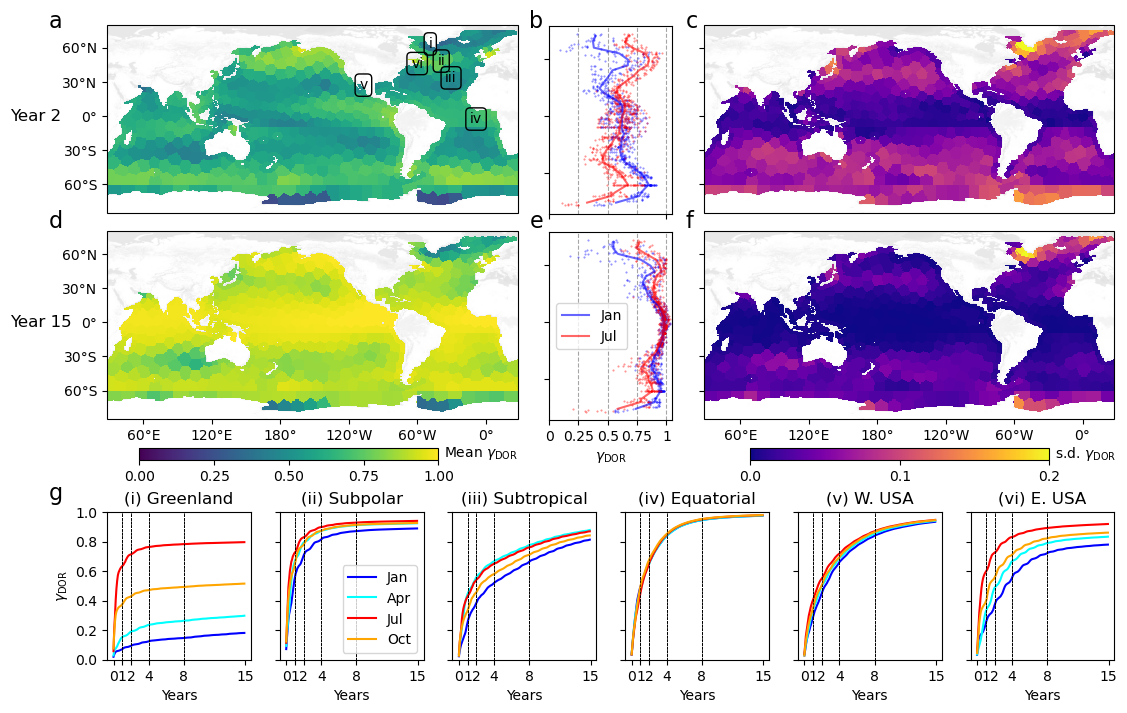

In [6]:
%%time
from scipy.stats import linregress

FONTSIZE = 10
def modify(ax):
    ax.set_extent([0, 360, -85, 80], crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=False)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter) 
    ax.imshow(imread('./lightearth.jpg'),origin='upper', transform=ccrs.PlateCarree(), extent=[-180, 180, -90, 90])
    #ax.stock_img()
    # ax.set_yticks([-60,-30,0,30,60], crs=ccrs.PlateCarree())
    # ax.set_yticklabels(ax.get_yticks(), fontsize=FONTSIZE)

central_longitude=208

labels = ['a', 'b', 'c', 'd', 'e', 'f']

fig = plt.figure(figsize=(13,8))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 1], height_ratios=[2.6, 1], wspace=0.55, hspace=0.2)

# Separate the first column into 2 rows
gs_sub1 = gs[0, :].subgridspec(2, 3, width_ratios=[1, 0.3, 1], wspace=0.1, hspace=0.04)
ax = plt.subplot(gs_sub1[0, 0], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax1 = plt.subplot(gs_sub1[0, 2], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax8 = plt.subplot(gs_sub1[1, 0], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax9 = plt.subplot(gs_sub1[1, 2], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax10 = plt.subplot(gs_sub1[0, 1])
ax11 = plt.subplot(gs_sub1[1, 1])
# Adjust ax10 height
pos10 = ax10.get_position()
new_height10 = pos10.height * 0.95  # shrink height to 60%, adjust as needed
# Shift down a bit to keep spacing consistent (optional)
new_y0_10 = pos10.y0 +0.005
ax10.set_position([pos10.x0, new_y0_10, pos10.width, new_height10])

# Adjust ax11 height similarly
pos11 = ax11.get_position()
new_height11 = pos11.height * 0.95
new_y0_11 = pos11.y0 +0.005
ax11.set_position([pos11.x0, new_y0_11, pos11.width, new_height11])


# Separate the second column into 3 rows, and only use the middle one
gs_sub2 = gs[1, :].subgridspec(1, 6, width_ratios=[1,1,1,1,1,1], wspace=0.2, hspace=0.5)
ax2 = plt.subplot(gs_sub2[0,0])
ax3 = plt.subplot(gs_sub2[0,1])
ax4 = plt.subplot(gs_sub2[0,2])
ax5 = plt.subplot(gs_sub2[0,3])
ax6 = plt.subplot(gs_sub2[0,4])
ax7 = plt.subplot(gs_sub2[0,5])

for axis in [ax2, ax3, ax4, ax5, ax6, ax7]:
    pos10 = axis.get_position()
    new_height10 = pos10.height * 0.95  # shrink height to 60%, adjust as needed
    # Shift down a bit to keep spacing consistent (optional)
    new_y0_10 = pos10.y0 -0.03
    axis.set_position([pos10.x0, new_y0_10, pos10.width, new_height10])

ax.text(0.08, 0.87, 'a', transform=fig.transFigure, fontsize=FONTSIZE+6)
ax.text(0.45, 0.87, 'b', transform=fig.transFigure, fontsize=FONTSIZE+6)
ax.text(0.57, 0.87, 'c', transform=fig.transFigure, fontsize=FONTSIZE+6)

ax.text(0.08, 0.62, 'd', transform=fig.transFigure, fontsize=FONTSIZE+6)
ax.text(0.45, 0.62, 'e', transform=fig.transFigure, fontsize=FONTSIZE+6)
ax.text(0.57, 0.62, 'f', transform=fig.transFigure, fontsize=FONTSIZE+6)

ax.text(0.08, 0.28, 'g', transform=fig.transFigure, fontsize=FONTSIZE+6)

########################## maps
vmin=0
vmax=1
cmap='viridis'


ax.pcolormesh(whole_ds_dor_mean.TLONG, whole_ds_dor_mean.TLAT, whole_ds_dor_mean.DOR_efficiency[2*12-1],
             transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
ax1.pcolormesh(whole_ds_dor_std.TLONG, whole_ds_dor_std.TLAT, whole_ds_dor_std.DOR_efficiency[2*12-1],
              transform=ccrs.PlateCarree(), cmap='plasma', vmin=0, vmax=0.2)

ax8.pcolormesh(whole_ds_dor_mean.TLONG, whole_ds_dor_mean.TLAT, whole_ds_dor_mean.DOR_efficiency[-1],
              transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
ax9.pcolormesh(whole_ds_dor_std.TLONG, whole_ds_dor_std.TLAT, whole_ds_dor_std.DOR_efficiency[-1],
              transform=ccrs.PlateCarree(), cmap='plasma', vmin=0, vmax=0.2)

ax.text(-265, 0, f'Year 2', rotation='horizontal', va='center', ha='left', fontsize=FONTSIZE+2)
ax8.text(-265, 0, f'Year 15', rotation='horizontal', va='center', ha='left', fontsize=FONTSIZE+2)

def add_ylabel(ax):
    ax.set_yticks([-60,-30,0,30,60], crs=ccrs.PlateCarree())
    ax.set_yticklabels(ax.get_yticks(), fontsize=FONTSIZE)
    
def add_xlabel(ax):
    ax.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())
    ax.set_xticklabels(ax.get_xticks(), fontsize=FONTSIZE)

add_ylabel(ax)
add_ylabel(ax8)
add_ylabel(ax1)
add_ylabel(ax9)
add_xlabel(ax8)
add_xlabel(ax9)

modify(ax)
modify(ax1)
modify(ax8)
modify(ax9)

ax1.set_yticklabels([])
ax9.set_yticklabels([])


def add_colorbar(x0, y0, vmin, vmax, label, num_levels_ticks, cmap_label='viridis'):
    '''
    x0, y0: start location for the colorbar
    vmin, vmax: range of the colorbar
    label: label of the colorbar'
    '''
    #cax = fig.add_axes([x0, y0, 0.01, 0.27])  # [x0, y0, width, height]
    cax = fig.add_axes([x0, y0, 0.23, 0.015])  # [x0, y0, width, height]
    cmap = plt.colormaps[cmap_label]
    normalize = plt.Normalize(vmin=vmin, vmax=vmax)  # Normalize the color values
    sm = cm.ScalarMappable(cmap=cmap, norm=normalize)
    cbar = fig.colorbar(sm, cax=cax, shrink=0.9, orientation='horizontal', ticks=np.linspace(vmin, vmax, num_levels_ticks))
    cbar.ax.tick_params(labelsize=FONTSIZE)
    cbar.ax.xaxis.label.set_size(FONTSIZE)
    #cbar.ax.set_title(label, fontsize=FONTSIZE, pad=10)  # adjust pad as needed
    cbar.ax.text(1.02, 0.5, label, fontsize=FONTSIZE, va='center', ha='left', transform=cbar.ax.transAxes) # Add label on the right side

# add_colorbar(0.43, 0.5, vmin, vmax, rf'Mean \n $\epsilon_{{\mathrm{{ERW}}}}$', 5, cmap_label=cmap)
# add_colorbar(0.92, 0.5, 0, 0.02, rf's.d. \n $\epsilon_{{\mathrm{{ERW}}}}$', 3, cmap_label='plasma')


add_colorbar(0.15, 0.33, vmin, vmax, rf'Mean $\gamma_{{\mathrm{{DOR}}}}$', 5, cmap_label=cmap)
add_colorbar(0.62, 0.33, 0, 0.2, rf's.d. $\gamma_{{\mathrm{{DOR}}}}$', 3, cmap_label='plasma')

########### Scatters

df_jan, mean_jan = extract_unique(whole_ds_dor.DOR_efficiency[0,2*12-1], window=60, bin_size=5)
df_jul, mean_jul = extract_unique(whole_ds_dor.DOR_efficiency[2,2*12-1], window=60, bin_size=5)
ax10.scatter(df_jan['val'], df_jan['lat'], s=0.2, color='blue', alpha=0.5)
ax10.plot(mean_jan['val'], mean_jan['lat'], color='blue', linewidth=1.5, label='Jan', alpha=0.6)
ax10.scatter(df_jul['val'], df_jul['lat'], s=0.2, color='red', alpha=0.5)
ax10.plot(mean_jul['val'], mean_jul['lat'], color='red', linewidth=1.5, label='Jul', alpha=0.6)
ax10.set_xlim(0, 1.05)

df_jan, mean_jan = extract_unique(whole_ds_dor.DOR_efficiency[0,-1], window=60, bin_size=5)
df_jul, mean_jul = extract_unique(whole_ds_dor.DOR_efficiency[2,-1], window=60, bin_size=5)
ax11.scatter(df_jan['val'], df_jan['lat'], s=0.2, color='blue', alpha=0.5)
ax11.plot(mean_jan['val'], mean_jan['lat'], color='blue', linewidth=1.5, label='Jan', alpha=0.6)
ax11.scatter(df_jul['val'], df_jul['lat'], s=0.2, color='red', alpha=0.5)
ax11.plot(mean_jul['val'], mean_jul['lat'], color='red', linewidth=1.5, label='Jul', alpha=0.6)
ax11.set_xlim(0, 1.05)

ax10.set_xticklabels([])
ax10.set_yticklabels([])
ax11.set_yticklabels([])

ax11.legend(loc='center left')
ax11.set_xlabel(rf'$\gamma_{{\mathrm{{DOR}}}}$')

ticks = np.arange(0, 1.05, 0.25)
ax11.set_xticks(ticks)
ax11.set_xticklabels(['0', '0.25', '0.5', '0.75', '1'])

# add vertical lines
for x in ticks:
    ax10.axvline(x=x, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)
    ax11.axvline(x=x, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

########### curves

sel_region = ['Atlantic', 'Atlantic', 'Atlantic', 'Atlantic', 'Pacific', 'Atlantic']
sel_polygon = [0, 126, 142, 129, 164-150, 72]
river_names = ['(i) Greenland', '(ii) Subpolar', '(iii) Subtropical', '(iv) Equatorial', '(v) W. USA', '(vi) E. USA']

time = np.arange(180)/12
colors = ['blue', 'cyan', 'red', 'orange']
labels = ['Jan', 'Apr', 'Jul', 'Oct']

dict_centers = {
    'Atlantic': Atlantic_centers,
    'Pacific': Pacific_centers,
}
### polygon locations
orders = ['i', 'ii', 'iii', 'iv', 'v', 'vi']
for r, p, o in zip(sel_region, sel_polygon, orders):
    lon, lat = dict_centers[r][p]
    ax.text(lon, lat, o,transform=ccrs.PlateCarree(),fontsize=FONTSIZE ,bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.3'))
    

def rm_nans(arr):
    return arr[~np.isnan(arr)]

axes = [ax2, ax3, ax4, ax5, ax6, ax7]
for i in range(len(sel_region)):
    for s in range(4):
        axes[i].plot(time, rm_nans(dor_curves.DOR_efficiency.sel(region=sel_region[i], polygon=sel_polygon[i]).isel(season=s)), color=colors[s], label=labels[s])
        axes[i].set_title(river_names[i])
        
        #axes[i].set_ylim(-0.2, 0)
        axes[i].set_yticklabels([])
        axes[i].set_ylim(0, 1)
        axes[i].set_xticks([0,1,2,4,8,15])
        axes[i].set_xticklabels(['0','1','2','4','8','15'])
        axes[i].set_xlabel('Years')
        # add vertical lines
        years_highlight = [1, 2, 4, 8]
        for p in range(len(years_highlight)):
            axes[i].axvline(years_highlight[p], linestyle='--', color='k',linewidth=0.5, )

# axes[0].set_yticks([-0.2, -0.15, -0.1, -0.05, 0])
# axes[0].set_yticklabels(['-0.2', ' -0.15', '-0.1', '-0.05', '0'])
axes[0].set_ylabel(rf'$\gamma_{{\mathrm{{DOR}}}}$')

ticks = np.arange(0, 1.05, 0.2)
axes[0].set_yticks(ticks)
axes[0].set_yticklabels([f"{t:.1f}" for t in ticks])

axes[1].legend()

plt.savefig('./figures/Figure_2.png', dpi=200, bbox_inches='tight')

## Figure S1

<timed exec>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


CPU times: user 51.1 s, sys: 6.24 s, total: 57.3 s
Wall time: 57.4 s


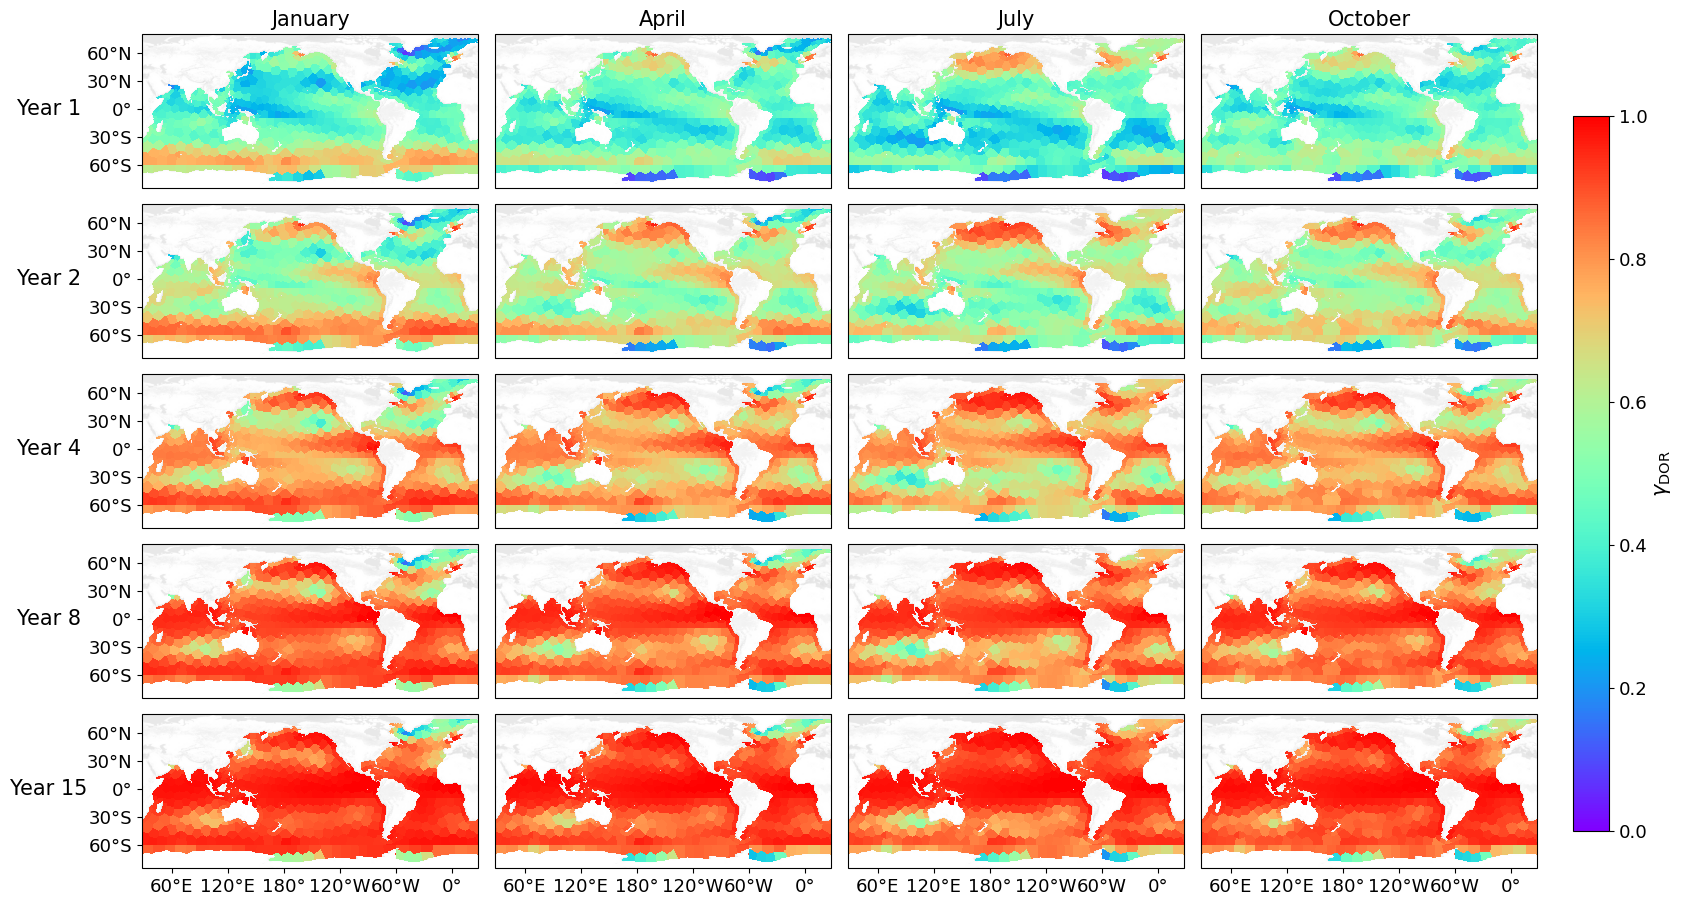

In [7]:
%%time
seasons = ['January', 'April', 'July', 'October']

from matplotlib import cm
FONTSIZE = 13

def modify(ax):
    ax.set_extent([0, 360, -85, 80], crs=ccrs.PlateCarree())
    
    lon_formatter = LongitudeFormatter(zero_direction_label=False)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)  
    ax.imshow(imread('./lightearth.jpg'),origin='upper', transform=ccrs.PlateCarree(), extent=[-180, 180, -90, 90])
    #ax.stock_img()

years = [1,2,4,8,15]

fig = plt.figure(figsize=(18,11))
for i in range(5):
    for j in range(4):
        ax = fig.add_subplot(5, 4, i*4+j+1, projection=ccrs.PlateCarree(central_longitude=208))

        ax.pcolormesh(whole_ds_dor.TLONG, whole_ds_dor.TLAT, whole_ds_dor.isel(season=j, N_month=(years[i])*12-1).DOR_efficiency, transform=ccrs.PlateCarree(), \
                         cmap='rainbow', 
                        vmin=0, vmax=1
                        )
        if i == 0:
            ax.set_title(f'{seasons[j]}', loc='center', fontsize=FONTSIZE+2)
        if j == 0:
            ax.set_yticks(np.arange(-60, 80, 30), crs=ccrs.PlateCarree())
            ax.set_yticklabels(ax.get_yticks(), fontsize=FONTSIZE)
            #ax.text(-280, 0, rf'$\eta_{{\mathrm{{DOR}}}}({years[i]})$', rotation='horizontal', va='center', ha='center', fontsize=FONTSIZE+2)
            ax.text(-280, 0, f'Year {years[i]}', rotation='horizontal', va='center', ha='center', fontsize=FONTSIZE+2)

        if i == 4:
            ax.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())
            ax.set_xticklabels(ax.get_xticks(), fontsize=FONTSIZE)

        modify(ax)

# Create a new axis for the colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.65])  # Adjust position and size as needed
cax.set_aspect(0.5)  # Adjust width
cax.set_aspect(20)  # Adjust height

cmap = cm.get_cmap('rainbow')  # Choose a colormap
normalize = plt.Normalize(vmin=0, vmax=1)  # Normalize the color values
sm = cm.ScalarMappable(cmap=cmap, norm=normalize)

cbar = fig.colorbar(sm, cax=cax, shrink=0.5, label='DOR efficiency')
cbar.ax.tick_params(labelsize=FONTSIZE)
cbar.ax.set_ylabel(rf'$\gamma_{{\mathrm{{DOR}}}}$', fontsize=FONTSIZE+2)

plt.subplots_adjust(wspace=0.05, hspace=0.02)

plt.savefig('./figures/Figure_S1.png', dpi=400, bbox_inches='tight')

## Figure S2

In [42]:
whole_ds_oae = xr.open_dataset('../data/oae_eff_maps.nc')
whole_ds_dor = xr.open_dataset('../data/dor_eff_maps.nc')

oae_mean = whole_ds_oae.mean(dim='season')
dor_mean = whole_ds_dor.mean(dim='season')

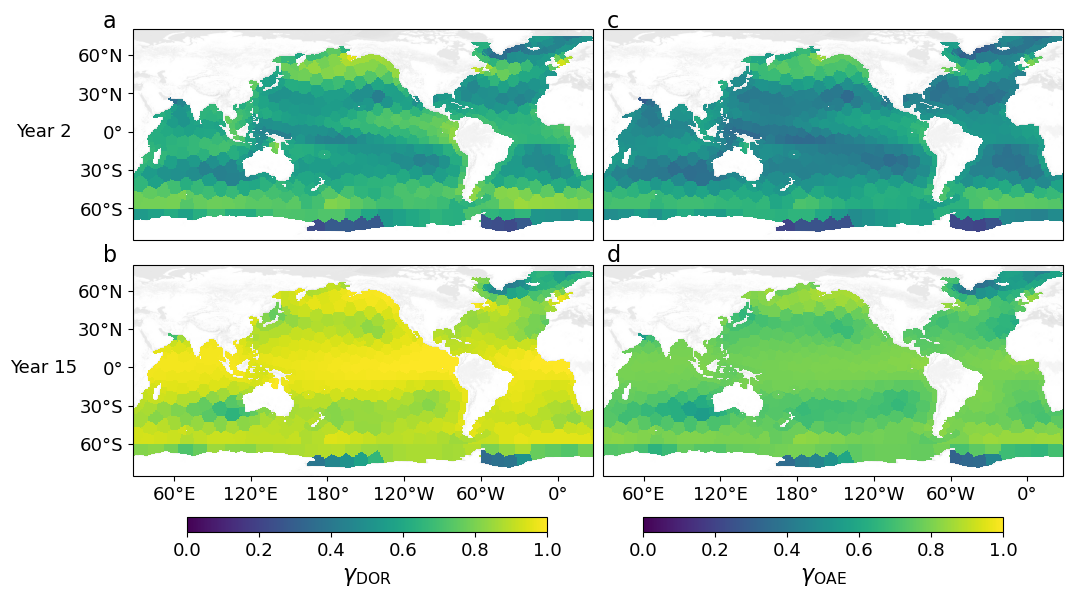

In [43]:
FONTSIZE = 13
def modify(ax):
    ax.set_extent([0, 360, -85, 80], crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=False)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter) 
    ax.imshow(imread('./lightearth.jpg'),origin='upper', transform=ccrs.PlateCarree(), extent=[-180, 180, -90, 90])

central_longitude=208

fig = plt.figure(figsize=(12,6))

vmin=0
vmax=1
cmap='viridis'

ax = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax1 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax3 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree(central_longitude=central_longitude))

ax.pcolormesh(whole_ds_dor.TLONG, whole_ds_dor.TLAT, dor_mean.DOR_efficiency.isel(N_month=2*12-1),
              transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
ax2.pcolormesh(whole_ds_dor.TLONG, whole_ds_dor.TLAT, dor_mean.DOR_efficiency.isel(N_month=15*12-1),
              transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)

ax1.pcolormesh(whole_ds_dor.TLONG, whole_ds_dor.TLAT, oae_mean.OAE_efficiency.isel(N_month=2*12-1),
              transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
ax3.pcolormesh(whole_ds_dor.TLONG, whole_ds_dor.TLAT, oae_mean.OAE_efficiency.isel(N_month=15*12-1),
              transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)

ax.text(0.10, 0.87, 'a', transform=fig.transFigure, fontsize=FONTSIZE+3)
ax1.text(0.52, 0.87, 'c', transform=fig.transFigure, fontsize=FONTSIZE+3)
ax2.text(0.10, 0.48, 'b', transform=fig.transFigure, fontsize=FONTSIZE+3)
ax3.text(0.52, 0.48, 'd', transform=fig.transFigure, fontsize=FONTSIZE+3)


ax.set_yticks([-60,-30,0,30,60], crs=ccrs.PlateCarree())
ax.set_yticklabels(ax.get_yticks(), fontsize=FONTSIZE)
ax2.set_yticks([-60,-30,0,30,60], crs=ccrs.PlateCarree())
ax2.set_yticklabels(ax2.get_yticks(), fontsize=FONTSIZE)
ax2.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())
ax2.set_xticklabels(ax2.get_xticks(), fontsize=FONTSIZE)
ax3.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())
ax3.set_xticklabels(ax3.get_xticks(), fontsize=FONTSIZE)
    
modify(ax)
modify(ax1)
modify(ax2)
modify(ax3)

def add_colorbar(x0, y0, vmin, vmax, label, num_levels_ticks, cmap_label='viridis'):
    '''
    x0, y0: start location for the colorbar
    vmin, vmax: range of the colorbar
    label: label of the colorbar'
    '''
    #cax = fig.add_axes([x0, y0, 0.013, 0.3])  # [x0, y0, width, height]
    cax = fig.add_axes([x0, y0, 0.3, 0.025])  # [x0, y0, width, height]
    cmap = plt.colormaps[cmap_label]
    normalize = plt.Normalize(vmin=vmin, vmax=vmax)  # Normalize the color values
    sm = cm.ScalarMappable(cmap=cmap, norm=normalize)
    cbar = fig.colorbar(sm, cax=cax, shrink=0.9, label=label, orientation='horizontal', ticks=np.linspace(vmin, vmax, num_levels_ticks))
    cbar.ax.tick_params(labelsize=FONTSIZE)
    cbar.ax.xaxis.label.set_size(FONTSIZE+3)

add_colorbar(0.17, 0.03, vmin, vmax, rf'$\gamma_{{\mathrm{{DOR}}}}$', 6, cmap_label=cmap)
add_colorbar(0.55, 0.03, vmin, vmax, rf'$\gamma_{{\mathrm{{OAE}}}}$', 6, cmap_label=cmap)

ax.text(-250, 0, f'Year 2', rotation='horizontal', va='center', ha='center', fontsize=FONTSIZE)
ax2.text(-250, 0, f'Year 15', rotation='horizontal', va='center', ha='center', fontsize=FONTSIZE)

plt.subplots_adjust(wspace=0.02, hspace=0.04)

plt.savefig('./figures/Figure_S2.png', dpi=200, bbox_inches='tight')

## Figure 5

In [18]:
oae_curves = xr.open_dataset('../data/oae_efficiency_curves.nc')
dor_curves = xr.open_dataset('../data/dor_efficiency_curves.nc')
ada_degass = oae_curves.OAE_efficiency - dor_curves.DOR_efficiency

In [19]:
whole_ds_ada = xr.open_dataset('../data/ada_eff_maps.nc')
whole_ds_ada = util.pop_add_cyclic(whole_ds_ada)
whole_ds_ada = whole_ds_ada.set_coords(['TLAT', 'TLONG'])

eta_max = xr.open_dataset('../data/eta_max_maps.nc')
eta_max = util.pop_add_cyclic(eta_max)
eta_max = eta_max.set_coords(['TLAT', 'TLONG'])

In [21]:
whole_ds_ada_mean = whole_ds_ada.mean(dim='season')
whole_ds_ada_std = whole_ds_ada.std(dim='season')

/global/homes/m/mzhou/miniconda3/envs/mcdr-atlas/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


/tmp/ipykernel_1159429/3946745841.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_vals = df.groupby('lat_bin')[['lat', 'val']].mean().dropna()
/tmp/ipykernel_1159429/3946745841.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_vals = df.groupby('lat_bin')[['lat', 'val']].mean().dropna()
/tmp/ipykernel_1159429/3946745841.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_vals = df.groupby('lat_bin

CPU times: user 14 s, sys: 1.2 s, total: 15.2 s
Wall time: 15.3 s


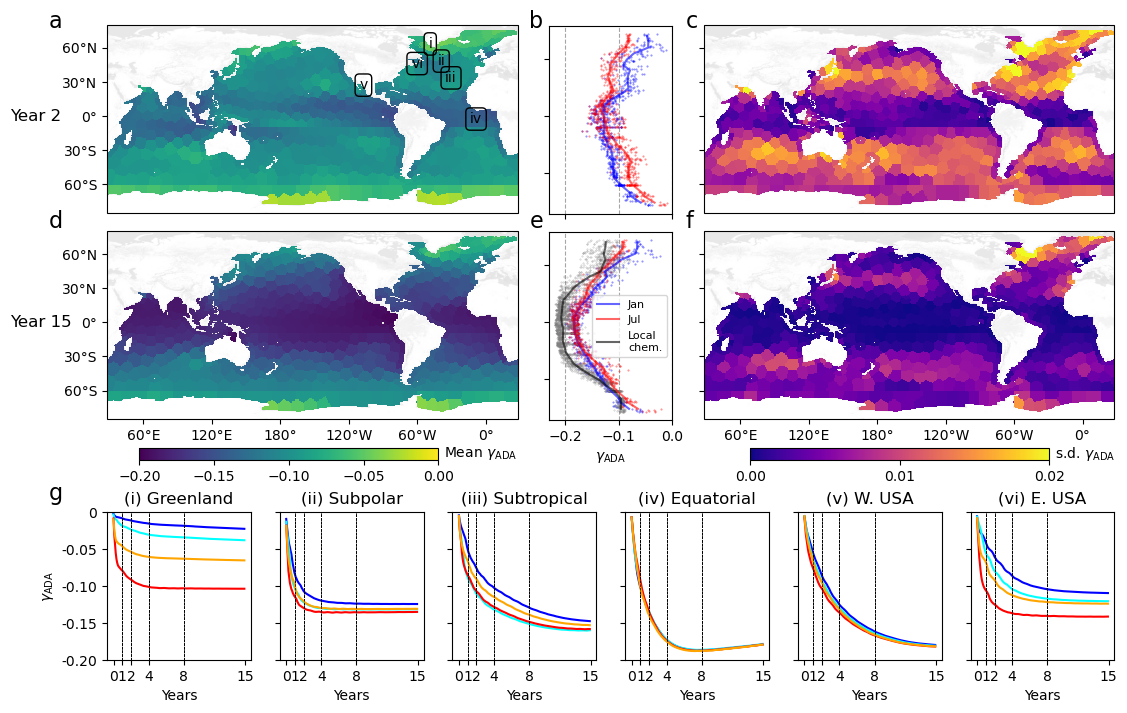

In [22]:
%%time
plt.rcParams.update({'font.size': 10})

from scipy.stats import linregress

FONTSIZE = 10
def modify(ax):
    ax.set_extent([0, 360, -85, 80], crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=False)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter) 
    ax.imshow(imread('./lightearth.jpg'),origin='upper', transform=ccrs.PlateCarree(), extent=[-180, 180, -90, 90])


central_longitude=208

labels = ['a', 'b', 'c', 'd', 'e', 'f']

fig = plt.figure(figsize=(13,8))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 1], height_ratios=[2.6, 1], wspace=0.55, hspace=0.2)

# Separate the first column into 2 rows
gs_sub1 = gs[0, :].subgridspec(2, 3, width_ratios=[1, 0.3, 1], wspace=0.1, hspace=0.04)
ax = plt.subplot(gs_sub1[0, 0], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax1 = plt.subplot(gs_sub1[0, 2], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax8 = plt.subplot(gs_sub1[1, 0], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax9 = plt.subplot(gs_sub1[1, 2], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax10 = plt.subplot(gs_sub1[0, 1])
ax11 = plt.subplot(gs_sub1[1, 1])
# Adjust ax10 height
pos10 = ax10.get_position()
new_height10 = pos10.height * 0.95  # shrink height to 60%, adjust as needed
# Shift down a bit to keep spacing consistent (optional)
new_y0_10 = pos10.y0 +0.005
ax10.set_position([pos10.x0, new_y0_10, pos10.width, new_height10])

# Adjust ax11 height similarly
pos11 = ax11.get_position()
new_height11 = pos11.height * 0.95
new_y0_11 = pos11.y0 +0.005
ax11.set_position([pos11.x0, new_y0_11, pos11.width, new_height11])


# Separate the second column into 3 rows, and only use the middle one
gs_sub2 = gs[1, :].subgridspec(1, 6, width_ratios=[1,1,1,1,1,1], wspace=0.2, hspace=0.5)
ax2 = plt.subplot(gs_sub2[0,0])
ax3 = plt.subplot(gs_sub2[0,1])
ax4 = plt.subplot(gs_sub2[0,2])
ax5 = plt.subplot(gs_sub2[0,3])
ax6 = plt.subplot(gs_sub2[0,4])
ax7 = plt.subplot(gs_sub2[0,5])

for axis in [ax2, ax3, ax4, ax5, ax6, ax7]:
    pos10 = axis.get_position()
    new_height10 = pos10.height * 0.95  # shrink height to 60%, adjust as needed
    # Shift down a bit to keep spacing consistent (optional)
    new_y0_10 = pos10.y0 -0.03
    axis.set_position([pos10.x0, new_y0_10, pos10.width, new_height10])

ax.text(0.08, 0.87, 'a', transform=fig.transFigure, fontsize=FONTSIZE+6)
ax.text(0.45, 0.87, 'b', transform=fig.transFigure, fontsize=FONTSIZE+6)
ax.text(0.57, 0.87, 'c', transform=fig.transFigure, fontsize=FONTSIZE+6)

ax.text(0.08, 0.62, 'd', transform=fig.transFigure, fontsize=FONTSIZE+6)
ax.text(0.45, 0.62, 'e', transform=fig.transFigure, fontsize=FONTSIZE+6)
ax.text(0.57, 0.62, 'f', transform=fig.transFigure, fontsize=FONTSIZE+6)

ax.text(0.08, 0.28, 'g', transform=fig.transFigure, fontsize=FONTSIZE+6)

########################## maps
vmin=-0.2
vmax=0
cmap='viridis'


ax.pcolormesh(whole_ds_ada_mean.TLONG, whole_ds_ada_mean.TLAT, whole_ds_ada_mean.ADA_efficiency[2*12-1],
             transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
ax1.pcolormesh(whole_ds_ada_std.TLONG, whole_ds_ada_std.TLAT, whole_ds_ada_std.ADA_efficiency[2*12-1],
              transform=ccrs.PlateCarree(), cmap='plasma', vmin=0, vmax=0.02)

ax8.pcolormesh(whole_ds_ada_mean.TLONG, whole_ds_ada_mean.TLAT, whole_ds_ada_mean.ADA_efficiency[-1],
              transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
ax9.pcolormesh(whole_ds_ada_std.TLONG, whole_ds_ada_std.TLAT, whole_ds_ada_std.ADA_efficiency[-1],
              transform=ccrs.PlateCarree(), cmap='plasma', vmin=0, vmax=0.02)

ax.text(-265, 0, f'Year 2', rotation='horizontal', va='center', ha='left', fontsize=FONTSIZE+2)
ax8.text(-265, 0, f'Year 15', rotation='horizontal', va='center', ha='left', fontsize=FONTSIZE+2)

def add_ylabel(ax):
    ax.set_yticks([-60,-30,0,30,60], crs=ccrs.PlateCarree())
    ax.set_yticklabels(ax.get_yticks(), fontsize=FONTSIZE)
    
def add_xlabel(ax):
    ax.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())
    ax.set_xticklabels(ax.get_xticks(), fontsize=FONTSIZE)

add_ylabel(ax)
add_ylabel(ax8)
add_ylabel(ax1)
add_ylabel(ax9)
add_xlabel(ax8)
add_xlabel(ax9)

modify(ax)
modify(ax1)
modify(ax8)
modify(ax9)

ax1.set_yticklabels([])
ax9.set_yticklabels([])


def add_colorbar(x0, y0, vmin, vmax, label, num_levels_ticks, cmap_label='viridis'):
    '''
    x0, y0: start location for the colorbar
    vmin, vmax: range of the colorbar
    label: label of the colorbar'
    '''
    #cax = fig.add_axes([x0, y0, 0.01, 0.27])  # [x0, y0, width, height]
    cax = fig.add_axes([x0, y0, 0.23, 0.015])  # [x0, y0, width, height]
    cmap = plt.colormaps[cmap_label]
    normalize = plt.Normalize(vmin=vmin, vmax=vmax)  # Normalize the color values
    sm = cm.ScalarMappable(cmap=cmap, norm=normalize)
    cbar = fig.colorbar(sm, cax=cax, shrink=0.9, orientation='horizontal', ticks=np.linspace(vmin, vmax, num_levels_ticks))
    cbar.ax.tick_params(labelsize=FONTSIZE)
    cbar.ax.xaxis.label.set_size(FONTSIZE)
    #cbar.ax.set_title(label, fontsize=FONTSIZE, pad=10)  # adjust pad as needed
    cbar.ax.text(1.02, 0.5, label, fontsize=FONTSIZE, va='center', ha='left', transform=cbar.ax.transAxes) # Add label on the right side


add_colorbar(0.15, 0.33, vmin, vmax, rf'Mean $\gamma_{{\mathrm{{ADA}}}}$', 5, cmap_label=cmap)
add_colorbar(0.62, 0.33, 0, 0.02, rf's.d. $\gamma_{{\mathrm{{ADA}}}}$', 3, cmap_label='plasma')

########### Scatters

df_jan, mean_jan = extract_unique(whole_ds_ada.ADA_efficiency[0,2*12-1], window=60, bin_size=5)
df_jul, mean_jul = extract_unique(whole_ds_ada.ADA_efficiency[2,2*12-1], window=60, bin_size=5)
ax10.scatter(df_jan['val'], df_jan['lat'], s=0.2, color='blue', alpha=0.5)
ax10.plot(mean_jan['val'], mean_jan['lat'], color='blue', linewidth=1.5, label='Jan', alpha=0.6)
ax10.scatter(df_jul['val'], df_jul['lat'], s=0.2, color='red', alpha=0.5)
ax10.plot(mean_jul['val'], mean_jul['lat'], color='red', linewidth=1.5, label='Jul', alpha=0.6)
ax10.set_xlim(-0.23, 0)

df_jan, mean_jan = extract_unique(whole_ds_ada.ADA_efficiency[0,-1], window=60, bin_size=5)
df_jul, mean_jul = extract_unique(whole_ds_ada.ADA_efficiency[2,-1], window=60, bin_size=5)
ax11.scatter(df_jan['val'], df_jan['lat'], s=0.2, color='blue', alpha=0.5)
ax11.plot(mean_jan['val'], mean_jan['lat'], color='blue', linewidth=1.5, label='Jan', alpha=0.6)
ax11.scatter(df_jul['val'], df_jul['lat'], s=0.2, color='red', alpha=0.5)
ax11.plot(mean_jul['val'], mean_jul['lat'], color='red', linewidth=1.5, label='Jul', alpha=0.6)
ax11.set_xlim(-0.23, 0)

## add the local chem. estimates
df_jan, df_mean = extract_unique(eta_max.eta_max[0], window=60, bin_size=5)
df_mean_seasons = np.empty((4, df_mean.val.shape[0]))
for s in range(4):
    df_jan, df_mean = extract_unique(eta_max.eta_max[s], window=60, bin_size=5)
    ax11.scatter(df_jan['val']-1, df_jan['lat'], s=0.1, color='gray', alpha=0.5)
    df_mean_seasons[s,:] = df_mean.val.values-1
ax11.plot(df_mean_seasons.mean(0), df_mean.lat, color='k', linewidth=1.5, label='Local\nchem.', alpha=0.6)

ticks = [-0.2,-0.1,0]
ax11.set_xticks(ticks)
ax10.set_xticklabels([])
ax10.set_yticklabels([])
ax11.set_yticklabels([])
ax11.legend(loc='center right', fontsize=8)
ax11.set_xlabel(rf'$\gamma_{{\mathrm{{ADA}}}}$')

# add vertical lines
for x in ticks:
    ax10.axvline(x=x, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)
    ax11.axvline(x=x, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)


########### curves

sel_region = ['Atlantic', 'Atlantic', 'Atlantic', 'Atlantic', 'Pacific', 'Atlantic']
sel_polygon = [0, 126, 142, 129, 164-150, 72]
#river_names = ['(i) Amazon', '(ii) Mississippi', '(iii) Yangtze', '(iv) W. USA', '(v) E. USA', '(vi) Greenland']
river_names = ['(i) Greenland', '(ii) Subpolar', '(iii) Subtropical', '(iv) Equatorial', '(v) W. USA', '(vi) E. USA']

time = np.arange(180)/12
colors = ['blue', 'cyan', 'red', 'orange']
labels = ['Jan', 'Apr', 'Jul', 'Oct']

dict_centers = {
    'Atlantic': Atlantic_centers,
    'Pacific': Pacific_centers,
}
### polygon locations
orders = ['i', 'ii', 'iii', 'iv', 'v', 'vi']
for r, p, o in zip(sel_region, sel_polygon, orders):
    lon, lat = dict_centers[r][p]
    ax.text(lon, lat, o,transform=ccrs.PlateCarree(),fontsize=FONTSIZE ,bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.3'))
    #ax8.text(lon, lat, o,transform=ccrs.PlateCarree(),fontsize=FONTSIZE ,bbox=dict(facecolor='lightgray', edgecolor='black', boxstyle='round,pad=0.3'))
    


def rm_nans(arr):
    return arr[~np.isnan(arr)]

axes = [ax2, ax3, ax4, ax5, ax6, ax7]
for i in range(len(sel_region)):
    for s in range(4):
        axes[i].plot(time, rm_nans(ada_degass.sel(region=sel_region[i], polygon=sel_polygon[i]).isel(season=s)), color=colors[s], label=labels[s])
        axes[i].set_title(river_names[i])
        
        axes[i].set_yticklabels([])
        axes[i].set_ylim(-0.2, 0)
        axes[i].set_xticks([0,1,2,4,8,15])
        axes[i].set_xticklabels(['0','1','2','4','8','15'])
        axes[i].set_xlabel('Years')
        # add vertical lines
        years_highlight = [1, 2, 4, 8]
        for p in range(len(years_highlight)):
            axes[i].axvline(years_highlight[p], linestyle='--', color='k',linewidth=0.5, )

axes[0].set_ylabel(rf'$\gamma_{{\mathrm{{ADA}}}}$')

ticks = np.arange(-0.2, 0.05, 0.05)
axes[0].set_yticks(ticks)
axes[0].set_yticklabels(["0" if np.isclose(t, 0) else f"{t:.2f}" for t in ticks])

    
plt.savefig('./figures/Figure_5.png', dpi=200, bbox_inches='tight')

## Figure S6

<timed exec>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


CPU times: user 51.5 s, sys: 6.17 s, total: 57.7 s
Wall time: 57.9 s


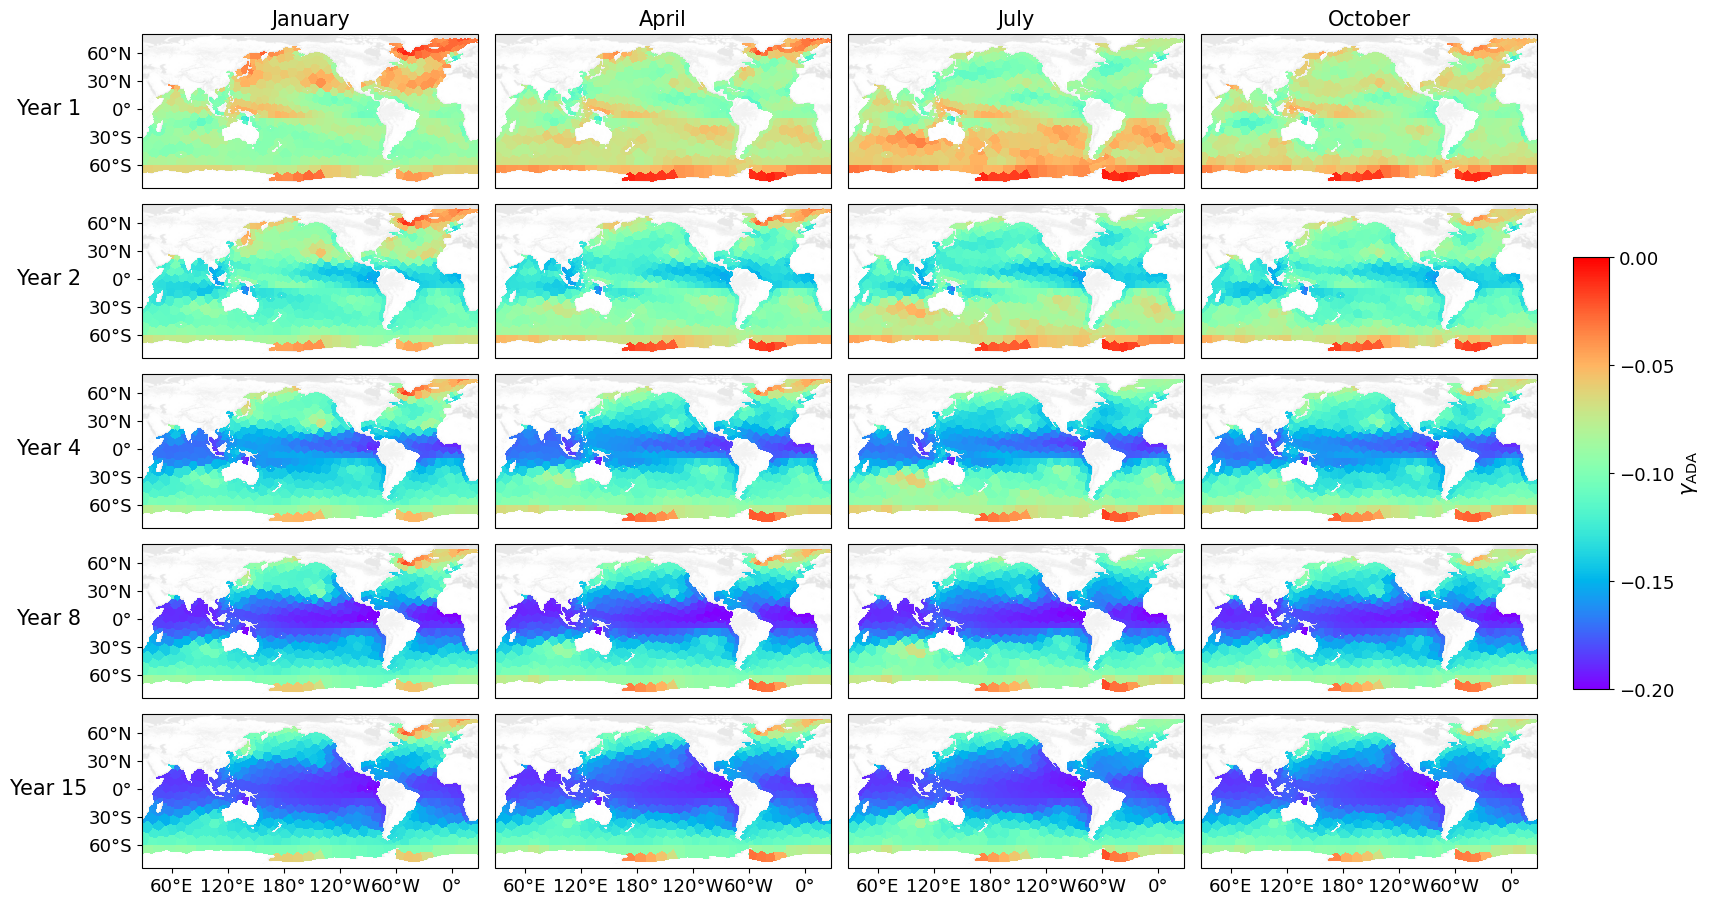

In [23]:
%%time
seasons = ['January', 'April', 'July', 'October']

from matplotlib import cm
FONTSIZE = 13

def modify(ax):
    ax.set_extent([0, 360, -85, 80], crs=ccrs.PlateCarree())
    
    lon_formatter = LongitudeFormatter(zero_direction_label=False)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)  
    ax.imshow(imread('./lightearth.jpg'),origin='upper', transform=ccrs.PlateCarree(), extent=[-180, 180, -90, 90])
    #ax.stock_img()

years = [1,2,4,8,15]

fig = plt.figure(figsize=(18,11))
for i in range(5):
    for j in range(4):
        ax = fig.add_subplot(5, 4, i*4+j+1, projection=ccrs.PlateCarree(central_longitude=208))

        ax.pcolormesh(whole_ds_ada.TLONG, whole_ds_ada.TLAT, whole_ds_ada.isel(season=j, N_month=(years[i])*12-1).ADA_efficiency, transform=ccrs.PlateCarree(), \
                         cmap='rainbow', 
                        vmin=-0.2, vmax=0
                        )
        if i == 0:
            ax.set_title(f'{seasons[j]}', loc='center', fontsize=FONTSIZE+2)
        if j == 0:
            ax.set_yticks(np.arange(-60, 80, 30), crs=ccrs.PlateCarree())
            ax.set_yticklabels(ax.get_yticks(), fontsize=FONTSIZE)
            #ax.text(-280, 0, rf'$\eta_{{\mathrm{{DOR}}}}({years[i]})$', rotation='horizontal', va='center', ha='center', fontsize=FONTSIZE+2)
            ax.text(-280, 0, f'Year {years[i]}', rotation='horizontal', va='center', ha='center', fontsize=FONTSIZE+2)

        if i == 4:
            ax.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())
            ax.set_xticklabels(ax.get_xticks(), fontsize=FONTSIZE)

        modify(ax)

# Create a new axis for the colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.65])  # Adjust position and size as needed
cax.set_aspect(0.5)  # Adjust width
cax.set_aspect(60)  # Adjust height

cmap = cm.get_cmap('rainbow')  # Choose a colormap
normalize = plt.Normalize(vmin=0.8-1, vmax=1-1)  # Normalize the color values
sm = cm.ScalarMappable(cmap=cmap, norm=normalize)

cbar = fig.colorbar(sm, cax=cax, shrink=1, label='ADA efficiency')
cbar.set_ticks(np.arange(0.8-1,1.01-1, 0.05))
cbar.ax.tick_params(labelsize=FONTSIZE)
cbar.ax.set_ylabel(rf'$\gamma_{{\mathrm{{ADA}}}}$', fontsize=FONTSIZE+2)

plt.subplots_adjust(wspace=0.05, hspace=0.02)

plt.savefig('./figures/Figure_S6.png', dpi=400, bbox_inches='tight')

## Figure S7 
ADA efficiency t=15 yr vs local

In [24]:
whole_ds_ada = xr.open_dataset('../data/ada_eff_maps.nc')
whole_ds_ada = util.pop_add_cyclic(whole_ds_ada)
whole_ds_ada = whole_ds_ada.set_coords(['TLAT', 'TLONG'])

eta_max = xr.open_dataset('../data/eta_max_maps.nc')
eta_max = util.pop_add_cyclic(eta_max)
eta_max = eta_max.set_coords(['TLAT', 'TLONG'])

<timed exec>:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


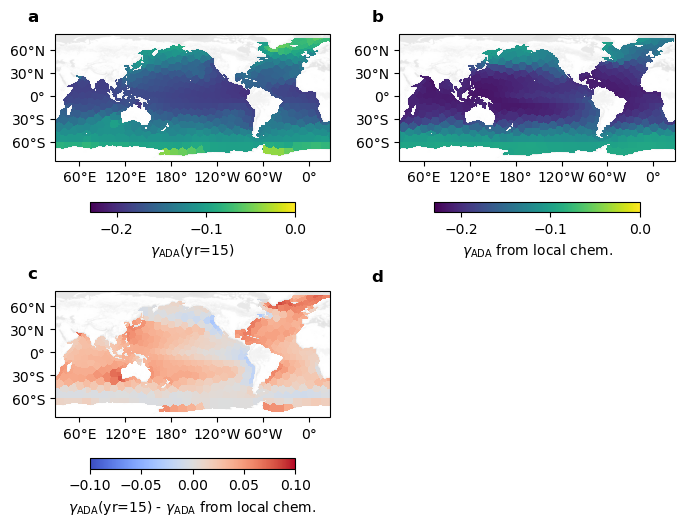

CPU times: user 8.19 s, sys: 1.6 s, total: 9.78 s
Wall time: 9.82 s


In [25]:
%%time
plt.rcParams.update({'font.size': 10})  

FONTSIZE = 10

def modify(ax):
    ax.set_extent([0, 360, -85, 80], crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=False)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter) 
    ax.imshow(imread('./lightearth.jpg'), origin='upper',
              transform=ccrs.PlateCarree(), extent=[-180, 180, -90, 90])
    ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
    ax.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=FONTSIZE)

central_longitude = 208

# Make bottom row (scatter) smaller in height and width
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1, 1],   # make right column narrower
    height_ratios=[1, 1],  # make bottom row shorter
    hspace=0.25, wspace=0.25
)

# Maps
ax1 = plt.subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax2 = plt.subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax3 = plt.subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax4 = plt.subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=central_longitude))

#ax4 = plt.subplot(gs[1, 1])

vmin, vmax = 0.77-1, 0
cmap = 'viridis'

# ---- Maps ----
pcm1 = ax1.pcolormesh(
    whole_ds_ada.TLONG, whole_ds_ada.TLAT,
    whole_ds_ada.ADA_efficiency.mean(dim='season').isel(N_month=-1),
    transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax
)
modify(ax1)

pcm2 = ax2.pcolormesh(
    whole_ds_ada.TLONG, whole_ds_ada.TLAT,
    eta_max.eta_max.mean(dim='season')-1,
    transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax
)
modify(ax2)

diff = whole_ds_ada.ADA_efficiency.isel(N_month=-1) - (eta_max.eta_max - 1)
pcm3 = ax3.pcolormesh(
    whole_ds_ada.TLONG, whole_ds_ada.TLAT,
    diff.mean(dim='season'),
    transform=ccrs.PlateCarree(), cmap='coolwarm', vmin=-0.1, vmax=0.1
)
modify(ax3)


# ---- Colorbars ----
cbar1 = fig.colorbar(pcm1, ax=ax1, orientation='horizontal', fraction=0.05, pad=0.2)
cbar1.set_label(r'$\gamma_{\mathrm{ADA}}$(yr=15)', fontsize=FONTSIZE)

cbar2 = fig.colorbar(pcm2, ax=ax2, orientation='horizontal', fraction=0.05, pad=0.2)
cbar2.set_label(r'$\gamma_{\mathrm{ADA}}$ from local chem.', fontsize=FONTSIZE)

cbar3 = fig.colorbar(pcm3, ax=ax3, orientation='horizontal', fraction=0.05, pad=0.2)
cbar3.set_label(r'$\gamma_{\mathrm{ADA}}$(yr=15) - $\gamma_{\mathrm{ADA}}$ from local chem.', fontsize=FONTSIZE)

# cbar4 = fig.colorbar(pcm4, ax=ax4, orientation='horizontal', fraction=0.05, pad=0.05)
# cbar4.set_label('Latitude', fontsize=FONTSIZE)


# ---- Panel labels ----
labels = ['a', 'b', 'c', 'd']  # add '(d)' if you include a fourth panel
axes = [ax1, ax2, ax3, ax4]  # add ax4 if you enable it later

for label, ax in zip(labels, axes):
    ax.text(
        -0.1, 1.2, label, 
        transform=ax.transAxes, 
        fontsize=FONTSIZE + 2, 
        fontweight='bold', 
        va='top', ha='left',
    )

for spine in ax4.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

fig.savefig('./figures/Figure_S7_part1.png', dpi=200, bbox_inches='tight')

CPU times: user 7.41 s, sys: 71.1 ms, total: 7.48 s
Wall time: 7.48 s


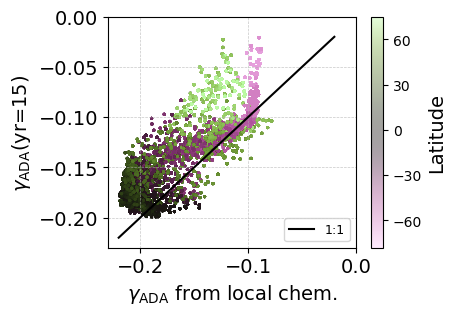

In [26]:
%%time
plt.rcParams.update({'font.size': 14})  

plt.figure(figsize=(4,3))

for i in range(4):
    plt.scatter(eta_max.eta_max.isel(season=i)-1, whole_ds_ada.ADA_efficiency.isel(season=i, N_month=-1), \
            c=whole_ds_ada.TLAT, s=1.5, cmap='vanimo', alpha=0.4)

plt.plot([0.78-1, 0.98-1], [0.78-1, 0.98-1], 'k-', label='1:1',)

plt.xlim(0.77-1, 1-1)
plt.ylim(0.77-1, 1-1)
plt.ylabel(rf'$\gamma_{{\mathrm{{ADA}}}}$(yr=15)')
plt.xlabel(rf'$\gamma_{{\mathrm{{ADA}}}}$ from local chem.')
cbar = plt.colorbar()
cbar.set_label("Latitude")
cbar.set_ticks([-60, -30, 0, 30, 60])
cbar.ax.tick_params(labelsize=10)  # set tick label font size

plt.legend(loc='lower right', fontsize=9)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


plt.savefig('./figures/Figure_S7_part2.png', dpi=100, bbox_inches='tight')

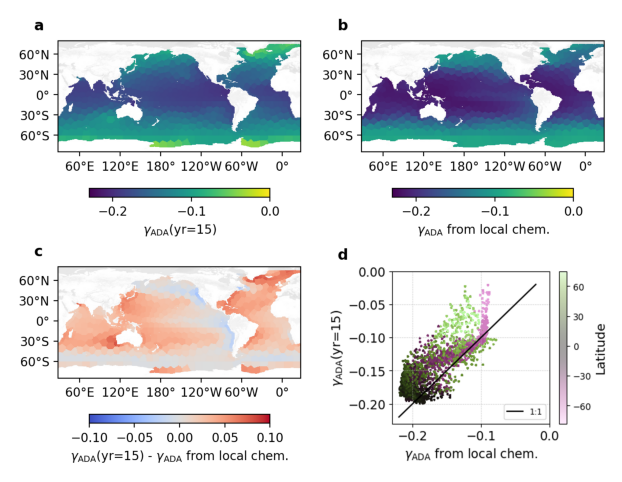

In [27]:
from PIL import Image
import matplotlib.pyplot as plt

# Open the two images
fig1 = Image.open('./figures/Figure_S7_part1.png')
fig2 = Image.open('./figures/Figure_S7_part2.png')

w1, h1 = fig1.size

# Resize fig2 to smaller fraction (e.g., 40% width and 40% height of fig1)
scale_factor = 0.45
new_w = int(w1 * 0.48)
new_h = int(h1 * scale_factor)
fig2_resized = fig2.resize((new_w, new_h))

# Paste coordinates (shifted down and right a bit)
paste_x = w1 - new_w   # 20 pixels from the right edge
paste_y = h1 - new_h - 9  # 30 pixels from the bottom edge

# Paste fig2 onto fig1
fig1.paste(fig2_resized, (paste_x, paste_y))

# Save the combined image
fig1.save('./figures/Figure_S7.png', dpi=(200, 200))

# Display
plt.figure(figsize=(8,6))
plt.imshow(fig1)
plt.axis('off')
plt.show()

## Figure S8 
ADA efficiency t=15yr vs. inf. 

In [28]:
whole_ds_box_model = xr.open_dataset(f'../data/box_model_result.nc')
whole_ds_box_model = whole_ds_box_model[['eta_max']]
whole_ds_box_model = util.pop_add_cyclic(whole_ds_box_model)

<timed exec>:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


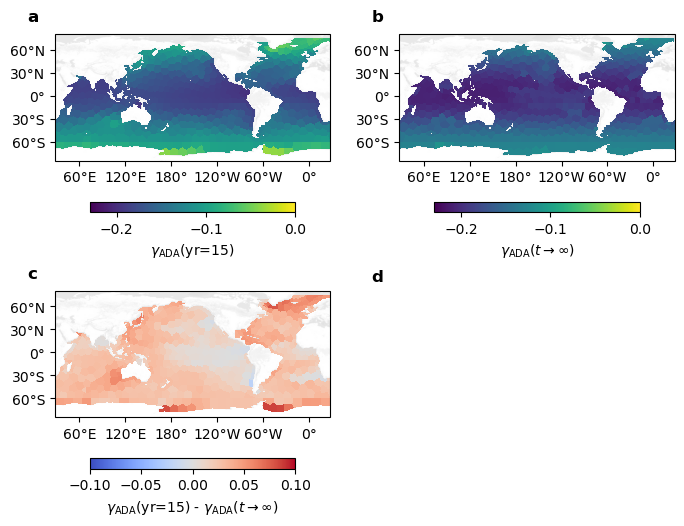

CPU times: user 8.4 s, sys: 1.21 s, total: 9.61 s
Wall time: 9.63 s


In [29]:
%%time
plt.rcParams.update({'font.size': 10})  
FONTSIZE = 10

def modify(ax):
    ax.set_extent([0, 360, -85, 80], crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=False)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter) 
    ax.imshow(imread('./lightearth.jpg'), origin='upper',
              transform=ccrs.PlateCarree(), extent=[-180, 180, -90, 90])
    ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
    ax.set_xticks(np.arange(0, 360, 60), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=FONTSIZE)

central_longitude = 208

# Make bottom row (scatter) smaller in height and width
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1, 1],   # make right column narrower
    height_ratios=[1, 1],  # make bottom row shorter
    hspace=0.25, wspace=0.25
)

# Maps
ax1 = plt.subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax2 = plt.subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax3 = plt.subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=central_longitude))
ax4 = plt.subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=central_longitude))

#ax4 = plt.subplot(gs[1, 1])

vmin, vmax = 0.77-1, 1-1
cmap = 'viridis'

# ---- Maps ----
pcm1 = ax1.pcolormesh(
    whole_ds_ada.TLONG, whole_ds_ada.TLAT,
    whole_ds_ada.ADA_efficiency.mean(dim='season').isel(N_month=-1),
    transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax
)
modify(ax1)

pcm2 = ax2.pcolormesh(
    whole_ds_box_model.TLONG, whole_ds_box_model.TLAT,
    whole_ds_box_model.eta_max.min(dim='season') - 1,
    transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax
)
modify(ax2)

diff = whole_ds_ada.ADA_efficiency.isel(N_month=-1).mean(dim='season') - (whole_ds_box_model.eta_max.mean(dim='season') - 1)
pcm3 = ax3.pcolormesh(
    whole_ds_ada.TLONG, whole_ds_ada.TLAT,
    diff,
    transform=ccrs.PlateCarree(), cmap='coolwarm', vmin=-0.1, vmax=0.1
)
modify(ax3)

# ---- Colorbars ----
cbar1 = fig.colorbar(pcm1, ax=ax1, orientation='horizontal', fraction=0.05, pad=0.2)
cbar1.set_label(r'$\gamma_{\mathrm{ADA}}$(yr=15)', fontsize=FONTSIZE)

cbar2 = fig.colorbar(pcm2, ax=ax2, orientation='horizontal', fraction=0.05, pad=0.2)
cbar2.set_label(r'$\gamma_{\mathrm{ADA}}$($t \to \infty$)', fontsize=FONTSIZE)

cbar3 = fig.colorbar(pcm3, ax=ax3, orientation='horizontal', fraction=0.05, pad=0.2)
cbar3.set_label(r'$\gamma_{\mathrm{ADA}}$(yr=15) - $\gamma_{\mathrm{ADA}}$($t \to \infty$)', fontsize=FONTSIZE)

# cbar4 = fig.colorbar(pcm4, ax=ax4, orientation='horizontal', fraction=0.05, pad=0.05)
# cbar4.set_label('Latitude', fontsize=FONTSIZE)


# ---- Panel labels ----
labels = ['a', 'b', 'c', 'd']  # add '(d)' if you include a fourth panel
axes = [ax1, ax2, ax3, ax4]  # add ax4 if you enable it later

for label, ax in zip(labels, axes):
    ax.text(
        -0.1, 1.2, label, 
        transform=ax.transAxes, 
        fontsize=FONTSIZE + 2, 
        fontweight='bold', 
        va='top', ha='left',
    )

for spine in ax4.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

fig.savefig('./figures/Figure_S8_part1.png', dpi=200, bbox_inches='tight')

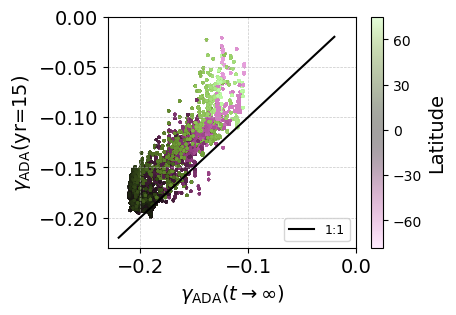

In [30]:
plt.rcParams.update({'font.size': 14})  

plt.figure(figsize=(4,3))

for i in range(4):
    plt.scatter(whole_ds_box_model.eta_max.isel(season=i) - 1, whole_ds_ada.ADA_efficiency.isel(season=i, N_month=-1), \
            c=whole_ds_box_model.TLAT, s=1.5, cmap='vanimo', alpha=0.4)

plt.plot([0.78-1, 0.98-1], [0.78-1, 0.98-1], 'k-', label='1:1',)
#plt.plot([0.9, 0.9], [0.77, 1], 'k--', label='Kanzaki et al. (2023)', )

plt.xlim(0.77-1, 1-1)
plt.ylim(0.77-1, 1-1)
plt.ylabel(rf'$\gamma_{{\mathrm{{ADA}}}}$(yr=15)')
plt.xlabel(rf'$\gamma_{{\mathrm{{ADA}}}}$($t \to \infty$)')
cbar = plt.colorbar()
cbar.set_label("Latitude")
cbar.set_ticks([-60, -30, 0, 30, 60])
cbar.ax.tick_params(labelsize=10)  # set tick label font size

plt.legend(loc='lower right', fontsize=9)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


plt.savefig('./figures/Figure_S8_part2.png', dpi=200, bbox_inches='tight')

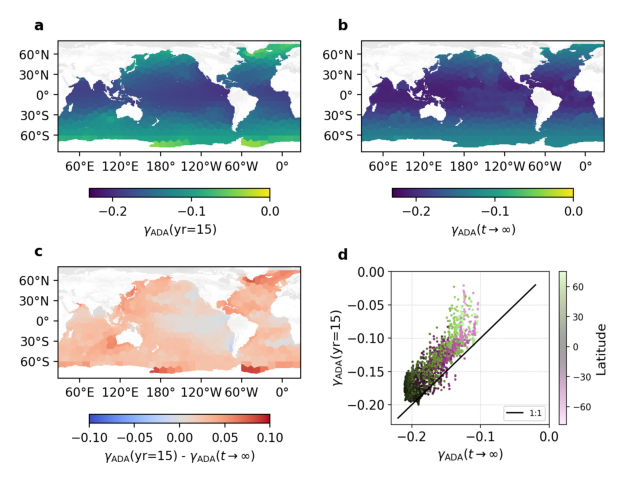

In [31]:
from PIL import Image
import matplotlib.pyplot as plt

# Open the two images
fig1 = Image.open('./figures/Figure_S8_part1.png')
fig2 = Image.open('./figures/Figure_S8_part2.png')

w1, h1 = fig1.size

# Resize fig2 to smaller fraction (e.g., 40% width and 40% height of fig1)
scale_factor = 0.45
new_w = int(w1 * 0.48)
new_h = int(h1 * scale_factor)
fig2_resized = fig2.resize((new_w, new_h))

# Paste coordinates (shifted down and right a bit)
paste_x = w1 - new_w   # 20 pixels from the right edge
paste_y = h1 - new_h - 9  # 30 pixels from the bottom edge

# Paste fig2 onto fig1
fig1.paste(fig2_resized, (paste_x, paste_y))

# Save the combined image
fig1.save('./figures/Figure_S8.png', dpi=(200, 200))

# Display
plt.figure(figsize=(8,6))
plt.imshow(fig1)
plt.axis('off')
plt.show()


## Box model vs. local carbonate chem.

CPU times: user 55.6 ms, sys: 0 ns, total: 55.6 ms
Wall time: 54.3 ms


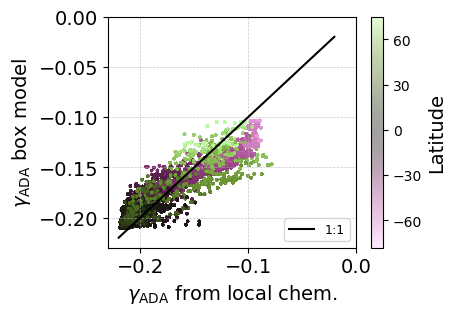

In [32]:
%%time
plt.rcParams.update({'font.size': 14})  

plt.figure(figsize=(4,3))

for i in range(4):
    plt.scatter(eta_max.eta_max.isel(season=i)-1, whole_ds_box_model.eta_max.isel(season=i) - 1, \
            c=whole_ds_ada.TLAT, s=1.5, cmap='vanimo', alpha=0.4)

plt.plot([0.78-1, 0.98-1], [0.78-1, 0.98-1], 'k-', label='1:1',)

plt.xlim(0.77-1, 1-1)
plt.ylim(0.77-1, 1-1)
plt.ylabel(rf'$\gamma_{{\mathrm{{ADA}}}}$ box model')
plt.xlabel(rf'$\gamma_{{\mathrm{{ADA}}}}$ from local chem.')
cbar = plt.colorbar()
cbar.set_label("Latitude")
cbar.set_ticks([-60, -30, 0, 30, 60])
cbar.ax.tick_params(labelsize=10)  # set tick label font size

plt.legend(loc='lower right', fontsize=9)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

#plt.savefig('./figures/erw_eff_local_box.png', dpi=100, bbox_inches='tight')

Text(0.5, 0, '% of difference \n (local chem. - box model ) / box model * 100 ')

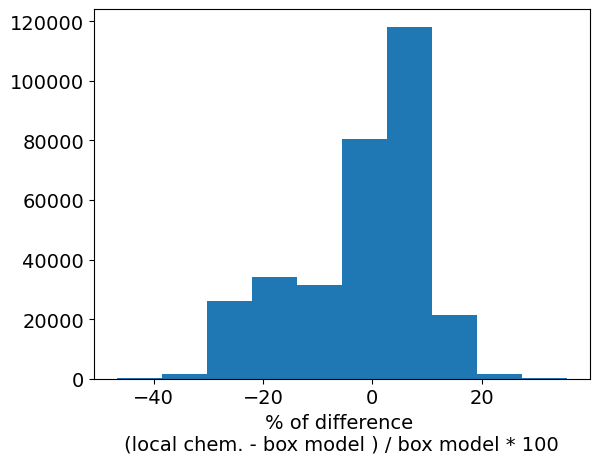

In [33]:
diff = eta_max.eta_max.values.flatten() - whole_ds_box_model.eta_max.values.flatten()
plt.hist(diff/(whole_ds_box_model.eta_max.values.flatten()-1)*100)
plt.xlabel('% of difference \n (local chem. - box model ) / box model * 100 ')

In [34]:
diff = whole_ds_ada.ADA_efficiency.isel(N_month=-1) - (eta_max.eta_max - 1)

In [35]:
box_model_estmates  = whole_ds_box_model.eta_max.values.flatten() - 1
cesm_estimates = whole_ds_ada.ADA_efficiency.isel(N_month=-1).values.flatten()
diff = box_model_estmates - cesm_estimates
diff_percent = np.unique(diff/(cesm_estimates)*100)
diff = np.unique(diff)

#plt.hist(diff/(cesm_estimates)*100)
#plt.xlabel('% of difference \n ( box model - cesm) / cesm * 100 ')

In [36]:
diff_percent.shape, diff.shape

((2761,), (2761,))

In [37]:
mean_diff = np.nanmean(diff_percent)
std_diff = np.nanstd(diff_percent)
mean_diff, std_diff, np.nanmin(diff_percent), np.nanmax(diff_percent), np.nanmedian(diff_percent)

(np.float64(23.12941966189866),
 np.float64(31.632404406074077),
 np.float64(-17.623476227741087),
 np.float64(506.68055645001056),
 np.float64(17.41024239968833))

In [38]:
ratio = np.unique(box_model_estmates /cesm_estimates)
np.nanmean(ratio), np.nanstd(ratio)

(np.float64(1.2312941966189865), np.float64(0.31632404406074077))

(array([  9., 250., 644., 865., 524., 217.,  74.,  37.,  31.,  17.,  18.,
         15.,   6.,  10.,   2.,   5.,   4.,   5.,   1.,   2.,   3.,   2.,
          0.,   3.,   1.,   0.,   3.,   3.,   1.,   1.,   3.,   0.,   1.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([-18.,  -8.,   2.,  12.,  22.,  32.,  42.,  52.,  62.,  72.,  82.,
         92., 102., 112., 122., 132., 142., 152., 162., 172., 182., 192.,
        202., 212., 222., 232., 242., 252., 262., 272., 282., 292., 302.,
        312., 322., 332., 342., 352., 362., 372., 382., 392., 402., 412.,
        422., 432., 442., 452., 462., 472., 482., 492.]),
 <BarContainer object of 51 artists>)

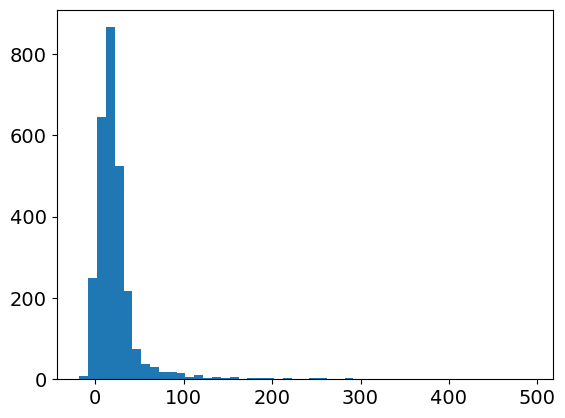

In [39]:
plt.hist(diff_percent.flatten(), bins=np.arange(-18, 500, 10))

In [40]:
np.nanmean(box_model_estmates < cesm_estimates)


np.float64(0.6137578692886813)